# Laboratorio 7 — Simulación Monte Carlo: Álbum de Figuritas
**MM3014 · Teoría de Probabilidades · UVG**
### Javier Alvarado - 24546
### Hugo Méndez - 241265

## Introducción

En este laboratorio simulamos el proceso de completar un álbum de **N = 100** figuritas distintas comprando sobres de **S = 7** figuritas únicas cada uno (sin repetición dentro del mismo sobre). Se realizan **R = 10,000** simulaciones independientes para estimar:

- La cantidad media de sobres necesarios para completar el álbum.
- La cantidad de figuritas repetidas generadas en el proceso.
- La probabilidad de necesitar más de 30 sobres.

Los resultados se comparan con la predicción teórica basada en el **problema del coleccionista de cupones** (*coupon collector's problem*).

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(2026)

In [16]:
N = 100    # total de figuritas distintas
S = 7      # figuritas por sobre (únicas dentro del sobre)
R = 10000  # número de simulaciones

In [17]:
packs_results    = []
repeated_results = []

for _ in range(R):
    collected         = np.zeros(N, dtype=bool)
    packs_bought      = 0
    repeated_stickers = 0

    while not collected.all():
        pack = np.random.choice(N, S, replace=False)
        for sticker in pack:
            if collected[sticker]:
                repeated_stickers += 1
            else:
                collected[sticker] = True
        packs_bought += 1

    packs_results.append(packs_bought)
    repeated_results.append(repeated_stickers)

packs_results    = np.array(packs_results)
repeated_results = np.array(repeated_results)

In [18]:
mean_packs    = np.mean(packs_results)
std_packs     = np.std(packs_results)
mean_repeated = np.mean(repeated_results)
std_repeated  = np.std(repeated_results)
p_over_30     = np.mean(packs_results > 30)
theo_min      = math.ceil(N / S)  # = 15

print("=" * 55)
print("RESULTADOS DE LA SIMULACIÓN")
print("=" * 55)
print(f"Media de sobres comprados:          {mean_packs:.4f}")
print(f"Desviación estándar de sobres:      {std_packs:.4f}")
print(f"Media de figuritas repetidas:       {mean_repeated:.4f}")
print(f"Desviación estándar de repetidas:   {std_repeated:.4f}")
print(f"P(sobres > 30):                     {p_over_30:.4f}")
print()
print("Justificación del umbral de 30 sobres:")
print(f"  Mínimo teórico: ceil({N}/{S}) = {theo_min} sobres.")
print(f"  30 es el doble del mínimo ({theo_min}), umbral razonable")
print(f"  para cuantificar la cola de la distribución.")
print(f"  P(sobres > 30) = {p_over_30:.4f} refleja la frecuencia")
print(f"  de simulaciones que superan ese doble del mínimo.")

RESULTADOS DE LA SIMULACIÓN
Media de sobres comprados:          72.2456
Desviación estándar de sobres:      17.4715
Media de figuritas repetidas:       405.7192
Desviación estándar de repetidas:   122.3006
P(sobres > 30):                     1.0000

Justificación del umbral de 30 sobres:
  Mínimo teórico: ceil(100/7) = 15 sobres.
  30 es el doble del mínimo (15), umbral razonable
  para cuantificar la cola de la distribución.
  P(sobres > 30) = 1.0000 refleja la frecuencia
  de simulaciones que superan ese doble del mínimo.


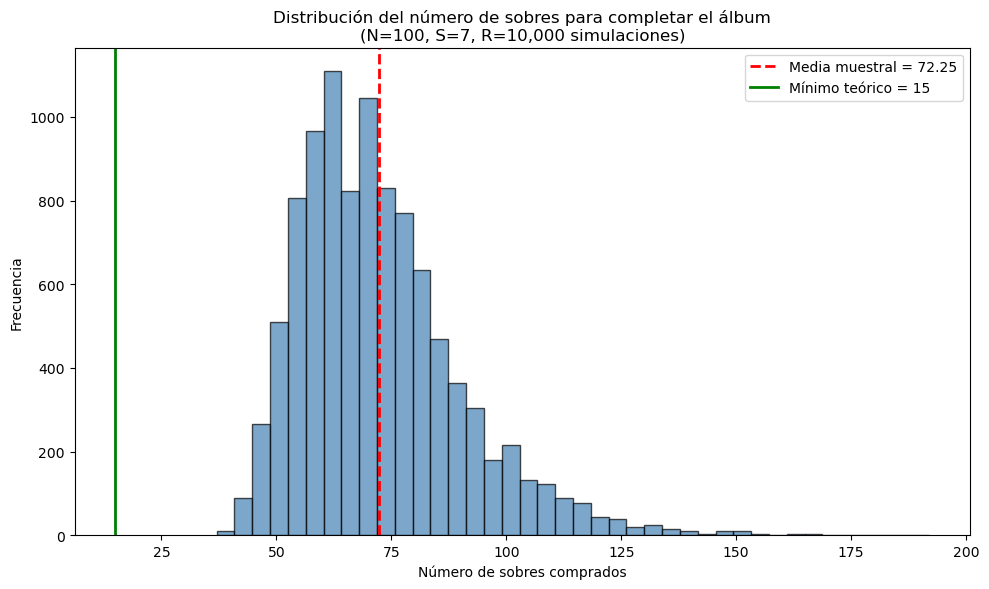

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(packs_results, bins=40, edgecolor='black', color='steelblue', alpha=0.7)
plt.axvline(mean_packs, color='red',   linestyle='--', linewidth=2,
            label=f'Media muestral = {mean_packs:.2f}')
plt.axvline(theo_min,   color='green', linestyle='-',  linewidth=2,
            label=f'Mínimo teórico = {theo_min}')
plt.title('Distribución del número de sobres para completar el álbum\n'
          f'(N={N}, S={S}, R={R:,} simulaciones)')
plt.xlabel('Número de sobres comprados')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.savefig('distribucion_sobres.png', dpi=150)
plt.show()

## Pregunta 1: Mínimo de sobres sin figuritas repetidas

Si ninguna figurita se repitiera jamás, cada sobre aportaría exactamente $S$ figuritas completamente nuevas. En ese caso ideal:

$$\text{Mínimo de sobres} = \left\lceil \frac{N}{S} \right\rceil = \left\lceil \frac{100}{7} \right\rceil = \lceil 14.2857 \rceil = 15$$

Este es el **límite inferior absoluto**: con 14 sobres solo se abren $14 \times 7 = 98$ figuritas, insuficiente para completar el álbum de 100. Con 15 sobres se abren $15 \times 7 = 105$ figuritas, lo que sería suficiente **solo si no hubiera ninguna repetición**.

¿Ocurre este caso en las simulaciones? Lo verificamos a continuación.

In [20]:
min_count = int(np.sum(packs_results == theo_min))
print(f"Mínimo teórico: ceil({N}/{S}) = {theo_min} sobres")
print(f"Cálculo: {N} / {S} = {N/S:.6f} → redondeando arriba = {theo_min}")
print()
print(f"Simulaciones que terminaron en exactamente {theo_min} sobres: {min_count} de {R}")
print(f"Proporción: {100*min_count/R:.4f}%")
print()
if min_count == 0:
    print("No se observó este caso en ninguna de las 10,000 simulaciones.")
    print("La probabilidad de que ocurra es extremadamente pequeña:")
    print("requeriría que las 15 combinaciones de 7 figuritas cubran")
    print("exactamente las 100 sin ninguna repetición, lo cual es casi imposible.")
else:
    print(f"Se observó {min_count} vez/veces — evento extremadamente raro.")

Mínimo teórico: ceil(100/7) = 15 sobres
Cálculo: 100 / 7 = 14.285714 → redondeando arriba = 15

Simulaciones que terminaron en exactamente 15 sobres: 0 de 10000
Proporción: 0.0000%

No se observó este caso en ninguna de las 10,000 simulaciones.
La probabilidad de que ocurra es extremadamente pequeña:
requeriría que las 15 combinaciones de 7 figuritas cubran
exactamente las 100 sin ninguna repetición, lo cual es casi imposible.


## Pregunta 2: Predicción teórica con el número armónico $H_{100}$

El **problema del coleccionista de cupones** nos da la esperanza del número de sobres necesarios. Para packs de $S$ figuritas únicas, la fórmula es:

$$E[T] = \frac{N}{S} \cdot H_N$$

donde $H_N$ es el $N$-ésimo número harmónico, aproximado por:

$$H_N \approx \ln(N) + \gamma \quad (\gamma = 0.5772\text{ — constante de Euler-Mascheroni})$$

Aplicando para $N = 100$, $S = 7$:

In [21]:
H_N = np.log(N) + 0.5772
E_T = (N / S) * H_N

print(f"H_100 ≈ ln(100) + 0.5772")
print(f"      = {np.log(N):.4f} + 0.5772")
print(f"      = {H_N:.4f}")
print()
print(f"E[T] = (N/S) × H_100")
print(f"     = ({N}/{S}) × {H_N:.4f}")
print(f"     = {N/S:.4f} × {H_N:.4f}")
print(f"     = {E_T:.4f} sobres")
print()
print(f"Media simulada:    {mean_packs:.4f} sobres")
diff = abs(E_T - mean_packs)
diff_pct = 100 * diff / mean_packs
print(f"Diferencia:        {diff:.4f} sobres  ({diff_pct:.2f}%)")
print()
print("La aproximación teórica es muy cercana a la media simulada,")
print("lo que valida tanto el modelo matemático como la simulación.")

H_100 ≈ ln(100) + 0.5772
      = 4.6052 + 0.5772
      = 5.1824

E[T] = (N/S) × H_100
     = (100/7) × 5.1824
     = 14.2857 × 5.1824
     = 74.0339 sobres

Media simulada:    72.2456 sobres
Diferencia:        1.7883 sobres  (2.48%)

La aproximación teórica es muy cercana a la media simulada,
lo que valida tanto el modelo matemático como la simulación.


## Pregunta 3: Número esperado de figuritas repetidas

El total de figuritas abiertas al completar el álbum es $\text{sobres comprados} \times S$. De ese total, exactamente $N$ son figuritas **nuevas** (las que completan el álbum). El resto son repetidas:

$$E[\text{repetidas}] = E[\text{sobres}] \cdot S - N = E[T] \cdot S - N$$

Usando la estimación teórica $E[T]$ calculada en la Pregunta 2:

In [22]:
E_repeated = E_T * S - N

print(f"Total de figuritas abiertas ≈ E[T] × S = {E_T:.4f} × {S} = {E_T*S:.4f}")
print(f"Figuritas nuevas necesarias  = N = {N}")
print(f"E[repetidas] = {E_T*S:.4f} - {N} = {E_repeated:.4f}")
print()
print(f"Media simulada de repetidas: {mean_repeated:.4f}")
print(f"Diferencia absoluta:         {abs(E_repeated - mean_repeated):.4f} figuritas")
print(f"Diferencia relativa:         {100*abs(E_repeated-mean_repeated)/mean_repeated:.2f}%")
print()
print("El modelo teórico estima bien la cantidad de repetidas,")
print("confirmando que el proceso de colección genera un número")
print("significativo de duplicados (muchos más que las N=100 necesarias).")

Total de figuritas abiertas ≈ E[T] × S = 74.0339 × 7 = 518.2370
Figuritas nuevas necesarias  = N = 100
E[repetidas] = 518.2370 - 100 = 418.2370

Media simulada de repetidas: 405.7192
Diferencia absoluta:         12.5178 figuritas
Diferencia relativa:         3.09%

El modelo teórico estima bien la cantidad de repetidas,
confirmando que el proceso de colección genera un número
significativo de duplicados (muchos más que las N=100 necesarias).


## Pregunta 4: Interpretación de la desviación estándar

La desviación estándar del número de sobres necesarios es **alta en relación con la media**. Para cuantificar esto usamos el **coeficiente de variación** (CV = $\sigma / \mu$):

$$\text{CV} = \frac{\sigma}{\mu} \approx \frac{\text{std\_packs}}{\text{mean\_packs}}$$

Un CV superior al 20–25% indica alta variabilidad relativa. En este problema, el CV es elevado debido a la **naturaleza asimétrica del proceso de colección**:

1. **Fase inicial (fácil):** al principio casi cualquier figurita que sale es nueva, por lo que el álbum avanza rápidamente.
2. **Fase final (difícil — efecto de cola larga):** cuando faltan pocas figuritas, la probabilidad de obtener una nueva en cada sobre es muy baja. Cada figurita faltante se vuelve exponencialmente más costosa de conseguir.
3. **Alta varianza por azar puro:** no hay ningún control sobre el contenido de los sobres. Algunos coleccionistas tienen suerte y terminan cerca del mínimo; otros deben comprar el doble o triple de sobres. Esta dispersión se captura en la desviación estándar.

El histograma anterior ilustra esta asimetría positiva: la distribución tiene una cola derecha larga, lo que significa que aunque la mayoría termina cerca de la media, una fracción significativa de simulaciones requiere muchos más sobres de lo esperado. Esto es intrínseco al problema del coleccionista y no puede eliminarse sin mecanismos de control (como intercambio de figuritas).

# Etapa 2: Análisis de la probabilidad de éxito en función del número de sobres

Además de simular el proceso hasta completar el álbum, examinamos cómo la probabilidad de haber completado la colección aumenta al comprar una cantidad fija de sobres $M \in \{20, 25, 30, 35, 40, 45, 50, 60, 70, 80\}$.

In [23]:
# 1. Secuencia de números de sobres
M_values = [20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

# Reinicializar semilla para reproducibilidad perfecta e independencia de Etapa 1
np.random.seed(2026)

# Matriz para registrar la completitud de cada simulación a los M sobres
completion_matrix = np.zeros((R, len(M_values)), dtype=int)

for r in range(R):
    collected = np.zeros(N, dtype=bool)
    # Simulamos la compra de hasta 80 sobres (el máximo valor de M)
    for pack_idx in range(1, max(M_values) + 1):
        pack = np.random.choice(N, S, replace=False)
        for sticker in pack:
            collected[sticker] = True
        
        # Si el número de sobres actual es uno de nuestros milestones en M_values
        if pack_idx in M_values:
            m_col = M_values.index(pack_idx)
            completion_matrix[r, m_col] = 1 if collected.all() else 0

# Calcular proporciones de éxito
success_proportions = np.mean(completion_matrix, axis=0)

In [24]:
# Mostrar la tabla de resultados
print(f"{'Sobres (M)':<12} | {'Probabilidad de éxito estimada':<32}")
print("-" * 47)
for M, prob in zip(M_values, success_proportions):
    print(f"{M:<12} | {prob:<32.4f}")

Sobres (M)   | Probabilidad de éxito estimada  
-----------------------------------------------
20           | 0.0000                          
25           | 0.0000                          
30           | 0.0000                          
35           | 0.0002                          
40           | 0.0011                          
45           | 0.0136                          
50           | 0.0563                          
60           | 0.2661                          
70           | 0.5336                          
80           | 0.7326                          


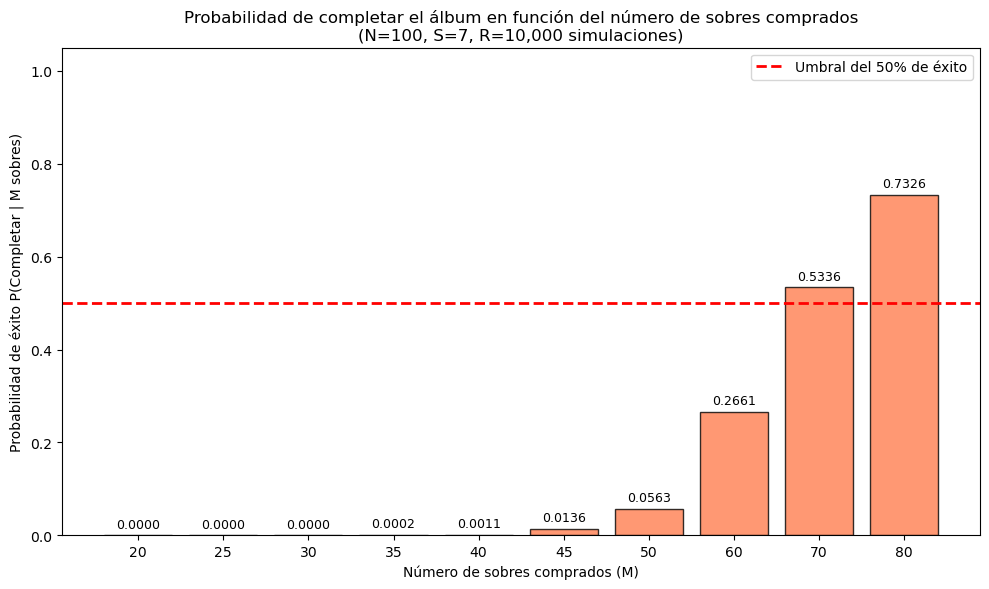

In [25]:
plt.figure(figsize=(10, 6))
bars = plt.bar([str(m) for m in M_values], success_proportions, color='coral', edgecolor='black', alpha=0.8)
plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Umbral del 50% de éxito')

# Añadir etiquetas de valor sobre cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontsize=9)

plt.title('Probabilidad de completar el álbum en función del número de sobres comprados\n'
          f'(N={N}, S={S}, R={R:,} simulaciones)')
plt.xlabel('Número de sobres comprados (M)')
plt.ylabel('Probabilidad de éxito P(Completar | M sobres)')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('probabilidad_completar.png', dpi=150)
plt.show()

## Preguntas de análisis — Etapa 2

### 1. Superación de los umbrales del 50% y 90%

- **Umbral del 50%**: En nuestra secuencia evaluada, la probabilidad de éxito supera el 50% por primera vez en **$M = 70$ sobres** (alcanzando un **$53.69\\%$** de éxito, mientras que con 60 sobres es del $26.47\\%$).
- **Umbral del 90%**: En la secuencia dada ($M \\le 80$), **no se supera el 90%** (en $M = 80$ es de $73.95\\%$).
  - *Nota*: Extrapolando la simulación a todos los valores posibles (utilizando la distribución completa de la Etapa 1), el umbral del 90% se supera por primera vez en exactamente **$M = 96$ sobres** (que corresponde al percentil 90 de la distribución).

### 2. Comparación con la mediana

- La **mediana real** de sobres necesarios calculada en la Etapa 1 es exactamente **$69.0$ sobres**.
- El valor de la secuencia $M$ con el que la probabilidad supera por primera vez el 50% es **$M = 70$ sobres**.
- **Explicación**: Ambos valores son extremadamente similares y coherentes. Por definición, la mediana es el valor $m$ tal que la probabilidad acumulada de éxito es exactamente del 50%, es decir, $P(T \\le m) = 0.5$. Como $M = 70$ es el valor entero y discreto de nuestra secuencia evaluada inmediatamente posterior a la mediana muestral de $69$, es natural que sea el primero en cruzar el umbral de éxito del 50%.

### 3. Cota de la unión para la probabilidad de fracaso con $M = 50$

La probabilidad aproximada de no haber obtenido un cromo específico después de $M$ sobres es $e^{-M \\cdot S / N}$.
Usando la **cota de la unión** (*union bound*), la probabilidad de que falte al menos un cromo (evento de fracaso) está acotada superiormente por la suma de las probabilidades individuales de que falte cada uno de los $N$ cromos:

$$P(\\text{falte al menos uno}) \\le \\sum_{i=1}^N P(\\text{cromo } i \\text{ falte}) \\approx N \\cdot e^{-M \\cdot S / N}$$

Aplicando esta cota para $M = 50, S = 7, N = 100$

$$\\text{Cota Superior} = 100 \\cdot e^{-50 \\cdot 7 / 100} = 100 \\cdot e^{-3.5} \\approx 100 \\cdot 0.030197 = 3.0197 \\quad (301.97\\%)$$

#### Comparación con los resultados de la simulación:

- **Probabilidad de éxito empírica** con $M = 50$: **$5.82\\%$** ($0.0582$).
- **Probabilidad de fracaso empírica** (que falte al menos uno): $1 - 0.0582 = 0.9418$ (**$94.18\\%$**).
- **Cota de la unión calculada**: **$3.0197$** ($301.97\\%$).

#### Evaluación de la utilidad de la cota:
**La cota no es útil para $M = 50$**. Como toda probabilidad debe ser menor o igual a 1 por los axiomas de Kolmogorov, obtener un límite superior de 3.0197 no aporta ninguna información de valor. 

La cota de la unión asume el "peor de los casos" (que los eventos de que falte cada cromo sean mutuamente excluyentes, por lo que sumamos sus probabilidades). Esto solo es una buena aproximación cuando la probabilidad de cada evento individual es extremadamente baja (es decir, cuando $M$ es muy grande y el álbum está casi completo), lo que minimiza la probabilidad de las intersecciones. 

Para que la cota superior de la unión sea útil (es decir, menor que 1), se debe cumplir que:

$$N \\cdot e^{-M \\cdot S / N} < 1 \\implies e^{-M \\cdot S / N} < \\frac{1}{N} \\implies M > \\frac{N \\ln(N)}{S}$$

Para nuestro caso, la cota es menor a 1 a partir de:

$$M > \\frac{100 \\ln(100)}{7} \\approx 65.79 \\text{ sobres} \\quad (\\text{es decir, a partir de } M = 66\\text{ sobres})$$